# nb06 · 参数辨识 / 拟合实验数据

本篇目标：用（合成或实测）放电数据**反推电池模型参数**。

流程：
1. 用一组「真实」参数跑模型，生成带噪声的合成实验数据（保存到 `data/`）。
2. 从偏离真值的初值出发，定义残差/代价函数。
3. 用 `scipy.optimize.least_squares` 优化，恢复参数。
4. 对比辨识前后的曲线拟合与参数误差。

> 方案选择：本篇用 **scipy** 实现，纯离线可跑。PyBaMM 官方还提供 [PyBOP](https://github.com/pybamm-team/PyBOP)
> 参数优化库（`pip install pybop`），接口更专业（`pybop.FittingProblem` + 多种优化器/采样器）；
> 末尾给出等价的 PyBOP 写法（可选）。

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm
from scipy.optimize import least_squares

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
print("PyBaMM 版本:", pybamm.__version__)

PyBaMM 版本: 26.6.1.1


## 1. 待辨识参数与正向模型

选两个影响放电曲线的参数作为待辨识对象：

- 负极活性物质体积分数 `Negative electrode active material volume fraction`
- 正极活性物质体积分数 `Positive electrode active material volume fraction`

用 SPM（最快）作正向模型，封装为「给定参数 → 输出 (时间, 电压)」的函数。

In [2]:
PARAM_NAMES = [
    "Negative electrode active material volume fraction",
    "Positive electrode active material volume fraction",
]
model = pybamm.lithium_ion.SPM()
_experiment = pybamm.Experiment(["Discharge at 1C until 2.8 V"])

def forward(theta):
    """给定参数向量 theta=[neg_frac, pos_frac]，返回 (时间[s], 端电压[V])。"""
    pv = pybamm.ParameterValues("Chen2020")
    pv[PARAM_NAMES[0]] = theta[0]
    pv[PARAM_NAMES[1]] = theta[1]
    sim = pybamm.Simulation(model, parameter_values=pv, experiment=_experiment)
    sol = sim.solve(initial_soc=1.0)
    return sol["Time [s]"].entries, sol["Terminal voltage [V]"].entries

## 2. 生成合成实验数据

设定一组「真实」参数（刻意偏离 Chen2020 默认值），跑模型并叠加测量噪声，保存为 CSV。
真实工作中这一步替换为你的实测放电数据即可。

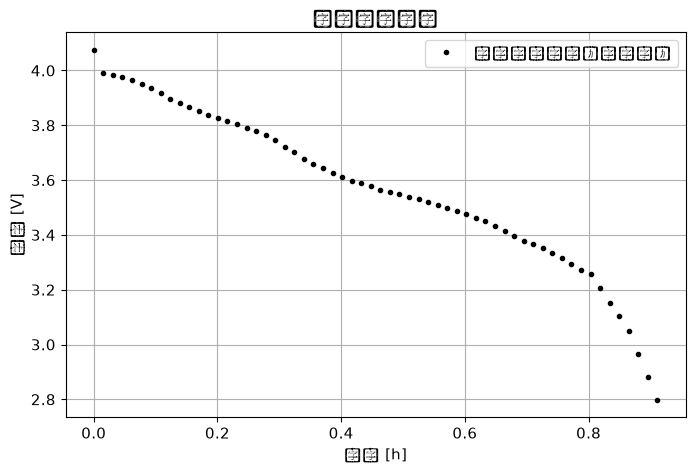

In [3]:
theta_true = np.array([0.70, 0.62])  # 真实参数（待辨识目标）

t_true, V_true = forward(theta_true)
t_data = np.linspace(t_true[0], t_true[-1], 60)
rng = np.random.default_rng(0)
V_clean = np.interp(t_data, t_true, V_true)
V_data = V_clean + rng.normal(0, 0.002, t_data.size)  # 2 mV 噪声

pd.DataFrame({"time [s]": t_data, "voltage [V]": V_data}).to_csv(
    os.path.join(DATA_DIR, "synthetic_discharge.csv"), index=False)

plt.plot(t_data / 3600, V_data, "k.", label="合成实验数据（含噪声）")
plt.xlabel("时间 [h]"); plt.ylabel("电压 [V]"); plt.title("合成放电数据"); plt.legend(); plt.show()

## 3. 定义残差并优化

残差 = 模型在数据时间点的插值电压 − 实测电压。从偏离真值的初值出发，用 `least_squares` 做有界优化。

In [4]:
def residual(theta):
    t, V = forward(theta)
    return np.interp(t_data, t, V) - V_data

theta0 = np.array([0.55, 0.50])           # 初值（故意偏离真值）
bounds = ([0.4, 0.4], [0.95, 0.95])

cost0 = 0.5 * np.sum(residual(theta0) ** 2)
result = least_squares(residual, theta0, bounds=bounds, xtol=1e-10, ftol=1e-10)
theta_fit = result.x
cost_fit = 0.5 * np.sum(result.fun ** 2)

print("参数         真值      初值      辨识值")
for i, name in enumerate(["neg_frac", "pos_frac"]):
    print(f"{name:9s} {theta_true[i]:8.4f} {theta0[i]:8.4f} {theta_fit[i]:8.4f}")
print(f"\n代价函数: 初值 {cost0:.4e} -> 辨识 {cost_fit:.4e}")

assert cost_fit < cost0 * 1e-2, "预期：辨识后代价显著下降"
assert np.allclose(theta_fit, theta_true, atol=0.02), "预期：辨识值接近真值"
print("校验通过：代价显著下降且参数接近真值。")

参数         真值      初值      辨识值
neg_frac    0.7000   0.5500   0.6999
pos_frac    0.6200   0.5000   0.6206

代价函数: 初值 1.7720e+00 -> 辨识 9.4844e-05
校验通过：代价显著下降且参数接近真值。


## 4. 辨识前后拟合对比

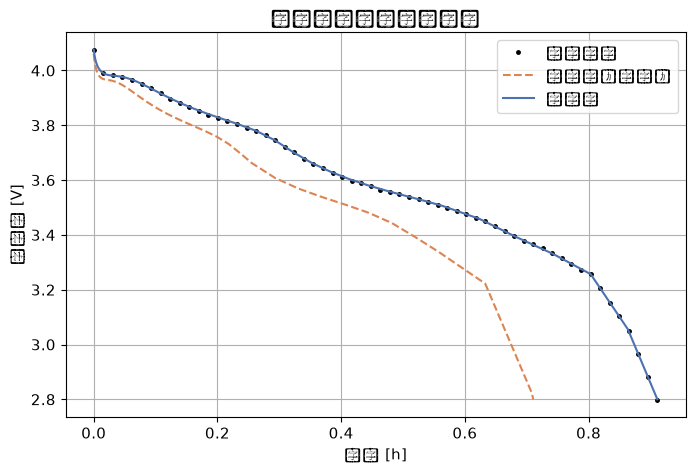

In [5]:
t0_, V0_ = forward(theta0)
tf_, Vf_ = forward(theta_fit)

plt.plot(t_data / 3600, V_data, "k.", ms=5, label="实验数据")
plt.plot(t0_ / 3600, V0_, "--", color="#DD8452", label="辨识前（初值）")
plt.plot(tf_ / 3600, Vf_, "-", color="#4C72B0", label="辨识后")
plt.xlabel("时间 [h]"); plt.ylabel("端电压 [V]")
plt.title("参数辨识前后拟合对比"); plt.legend(); plt.show()

## 5.（可选）用 PyBOP 实现等价辨识

若已安装 PyBOP（`pip install pybop`），可用更专业的接口完成同样任务。下面的 cell 在缺少 PyBOP 时会**自动跳过**，不影响 notebook 跑通。

In [6]:
try:
    import pybop

    parameters = pybop.Parameters(
        pybop.Parameter(PARAM_NAMES[0], prior=pybop.Uniform(0.4, 0.95), bounds=[0.4, 0.95]),
        pybop.Parameter(PARAM_NAMES[1], prior=pybop.Uniform(0.4, 0.95), bounds=[0.4, 0.95]),
    )
    dataset = pybop.Dataset({
        "Time [s]": t_data,
        "Current function [A]": np.full_like(t_data, pybamm.ParameterValues("Chen2020")["Nominal cell capacity [A.h]"]),
        "Voltage [V]": V_data,
    })
    pybop_model = pybop.lithium_ion.SPM(parameter_set=pybamm.ParameterValues("Chen2020"))
    problem = pybop.FittingProblem(pybop_model, parameters, dataset)
    cost = pybop.SumSquaredError(problem)
    optim = pybop.Optimisation(cost, optimiser=pybop.SciPyMinimize)
    x, _ = optim.run()
    print("PyBOP 辨识值:", x)
except ImportError:
    print("未安装 PyBOP，跳过（上面的 scipy 路径已完成辨识）。如需安装: pip install pybop")

未安装 PyBOP，跳过（上面的 scipy 路径已完成辨识）。如需安装: pip install pybop


## 小结

- 参数辨识 = 调参数使**模型输出逼近实测数据**：封装正向模型 → 定义残差 → 优化。
- `scipy.optimize.least_squares` 即可完成，纯离线；PyBOP 提供更专业的辨识/不确定性量化接口。
- **注意事项**：
  - *可辨识性*——若两参数对曲线影响高度相关，可能无法唯一确定；选「作用机理不同」的参数更稳。
  - *初值敏感性*——非凸问题可能陷入局部解，建议多初值或全局优化。
  - *真实数据*——把第 2 节的合成数据替换为实测 CSV（含 SOC/温度记录更佳），并对齐截止条件。
- 至此电池建模系列（nb01–nb06）完成：基础仿真 → 参数/倍率 → 工况 → 热 → 老化 → 辨识。